<center>
<img src="https://drive.google.com/uc?id=1f1gGVI-rxcHjA90WEGNvvtSXF1pAxQwg" alt="Fasilkom UI" width="300"/>

CSCE604037 • Penambangan Data

Semester Genap 2024/2025

Fakultas Ilmu Komputer, Universitas Indonesia

## **Lab 9: *Text and Web Mining***

### **Tenggat Waktu: 3 Mei 2025, 23.59 WIB**
</center>

### **Ketentuan:**

1. Dokumen *template* lab dengan format .ipynb dan dataset (jika dibutuhkan) telah disediakan di SCeLE.
2. Jalankan kode pada dokumen .ipynb dan perhatikan dengan saksama apa yang potongan kode tersebut lakukan beserta dengan keluarannya. Jawablah pertanyaan yang disisipkan pada potongan program yang diberikan.
3. Dokumen Jupyter Notebook yang telah dilengkapi dengan jawaban dikumpulkan dengan format penamaan **Kelas_LabX_NPM_Nama.ipynb**. Contoh: A_Lab9_2106630473_CalistaVimalamettaHeryadi.ipynb
4. Kumpulkan dokumen tersebut pada submisi yang telah disediakan di SCeLE sebelum tenggat waktu yang ditentukan. Keterlambatan pengumpulan akan dikenakan penalti sebanyak **satu poin per menit**.
5. Lab ini dirancang sebagai **tugas mandiri**. Plagiarisme tidak diperkenankan dalam bentuk apapun. Adapun kolaborasi berupa diskusi (tanpa menyalin maupun mengambil jawaban orang lain) dan literasi masih diperbolehkan dengan mencantumkan kolaborator dan sumber.

**Nama**: Mohamad Arvin Fadriansyah

**Kelas**: A

**NPM**: 2006596996

**Kolaborator** (jika ada):
- Nama - NPM

**Referensi** (jika ada):
- [Referensi](https://example.com)

In [1]:
# may need to restart session after running this
# !pip install gensim

In [14]:
# imports here
import gensim
import gensim.downloader

## *Web Scraping*

Pada tugas ini Anda diminta melakukan *scraping* sederhana untuk mendapatkan data buku-buku yang paling disukai pengguna [Goodreads](https://www.goodreads.com/), sebuah website untuk menilai dan mendapatkan rekomendasi buku.

### *Notes*

Web scraping sederhana dapat dilakukan dengan *library* `BeautifulSoup`. Ia bekerja dengan mencari data yang diinginkan pada *source code* sebuah halaman (Anda dapat mengaksesnya dengan `Ctrl+U` pada *browser*). Berikut adalah contoh kodenya:

```
import bs4, requests

response = requests.get("<URL>")
soup = bs4.BeautifulSoup(response.txt, "html.parser")
some_tag = soup.find("<html_tag>")
text = some_tag.get_text()
```

`find()` mengembalikan sebuah *tag* sesuai argumen yang Anda berikan beserta isinya. Untuk mendapatkan semua kemunculan *tag* tersebut, gunakan `find_all()`. Keduanya dapat dipanggil secara bersarang. Untuk mendapatkan isi teks tanpa *tag*, gunakan `get_text()`. Silakan lihat [dokumentasi](https://www.crummy.com/software/BeautifulSoup/bs4/doc/) untuk fitur-fitur yang lebih kompleks.

Ada beberapa konsiderasi yang perlu Anda perhatikan saat melakukan *web scraping*, di antaranya:

- Perhatikan `robots.txt`

  Sebuah website umumnya memiliki *path* `/robots.txt` dari *root directory* yang menampilkan daftar *path* apa saja tidak boleh diakses perangkat otomatis seperti *scraper*. Aturan ini tidak benar-benar mencegah kegiatan *scraping*, tetapi sebaiknya kita mematuhi aturan pada *website* yang kita kunjungi.

- Tambahkan jeda di antara *request*

  Jeda tidak hanya membuat *scraper* Anda meniru perilaku manusia, mengurangi kemungkinan *scraper* dikenali oleh *website*, tetapi juga mengurangi beban pada *server website*.

- Menspesifikasikan *user agent* saat mengajukan *request*

  Sama seperti jeda, *user agent* membuat *scraper* Anda seakan-akan berasal dari pengguna sungguhan.

**Anda diharapkan melakukan ketiga hal di atas pada tugas ini.**

In [3]:
# !pip install bs4

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import requests
from bs4 import BeautifulSoup
import time, random
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import re
from gensim import downloader
from gensim.models import Word2Vec
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
from tqdm import tqdm

In [9]:
# User agent for scraping
HEADERS      = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                   "AppleWebKit/537.36 (KHTML, like Gecko) "
                   "Chrome/120.0.0.0 Safari/537.36"),
    "Accept-Language": "en-US,en;q=0.9",
}

### Soal 1a

Buku yang Anda perlu kumpulkan datanya tersedia pada daftar *Best Books Ever*, yang dapat dikunjungi melalui URL https://www.goodreads.com/list/show/1.Best_Books_Ever.

Walaupun terdapat ribuan buku dalam *Best Books Ever*, Anda akan melihat bahwa halaman tersebut hanya memuat 100 buku pertama. Untuk melihat buku-buku selanjutnya, Anda perlu menekan tombol *previous*, *next*, atau salah satu nomor halaman yang tersedia di bawah daftar buku. URL perlu dilengkapi dengan query string `?page=<nomor_halaman>` untuk menentukan halaman keberapa yang dimuat. Fitur ini disebut *pagination*, dan manfaatnya adalah menurunkan *load* website sekaligus meningkatkan *user experience* ketika konten yang ditampilkan sangat banyak.

**Lengkapi fungsi `scrape_list_pages` berikut yang:**
- Menerima *list* berisi URL semua halaman daftar buku. Karena nomor halaman terbawah adalah 100, maka *list* ini seharusnya berisi 100 URL.
- Mengembalikan *list* berisi URL semua buku yang Anda temukan pada halaman daftar buku. Karena setiap halaman memuat 100 buku, maka *list* ini seharusnya berisi 10000 URL.

In [10]:
base_url = "https://www.goodreads.com/list/show/1.Best_Books_Ever?page={}"
list_urls = [base_url.format(i) for i in range(1, 101)]

In [ ]:
def scrape_list_pages(list_urls):
    book_urls = []
    for url in list_urls:
        resp = requests.get(url, headers= HEADERS)
        soup = BeautifulSoup(resp.text, "html.parser")
        links = soup.select("a.bookTitle")
        for link in links:
            href = link.get("href")
            full = "https://www.goodreads.com" + href if href.startswith("/") else href
            book_urls.append(full)
        time.sleep(random.uniform(1, 3))
    return book_urls

**Panggil fungsi tersebut di sini:**

In [12]:
# TODO
book_urls = scrape_list_pages(list_urls)
print(f"Total book URLs: {len(book_urls)}")  # expect ~10000

Total book URLs: 10000


### Soal 1b

Sekarang Anda akan mengunjungi URL setiap buku untuk mengumpulkan data buku, contohnya adalah https://www.goodreads.com/book/show/1885.Pride_and_Prejudice.

**Lengkapi fungsi `scrape_book_page` berikut yang:**
- Menerima URL untuk sebuah buku
- Mengembalikan tiga jenis data:
  - Judul buku (apabila tidak ditemukan kembalikan `None`)
  - Deskripsi buku (apabila tidak ditemukan kembalikan `None`)
  - *List* berisi *genre* buku (ambil 7 *genre* pertama; apabila tidak ditemukan kembalikan *list* kosong)

In [13]:
import requests
import time
import random
import json
import re
import urllib.parse
from bs4 import BeautifulSoup
from tqdm import tqdm

# ──────────────── Config ──────────────── #

RETRIES      = 3
PAUSE_RANGE  = (0.5, 2.0)   # delay acak antar-request

# ─────────────── 1. Genre helper ─────────────── #
def fetch_more_genres(book_url: str) -> list[str]:
    """
    Panggil endpoint JSON goodreads.com/book/genres/<book_id>
    untuk mendapat genre tambahan yang tersembunyi di "...more".
    """
    path    = urllib.parse.urlparse(book_url).path
    if "/book/show/" in path:
        book_id = path.split("/")[3]
    else:
        book_id = urllib.parse.unquote(path).split("/")[-1].split(".")[0]
    api_url = f"https://www.goodreads.com/book/genres/{book_id}"

    try:
        r = requests.get(api_url, headers=HEADERS, timeout=10)
        if r.status_code != 200:
            return []
        data = r.json()
        return [g["name"].strip().lower() for g in data.get("genres", [])]
    except Exception:
        return []

# ─────────────── 2. HTML → (title, desc, genres) ─────────────── #
def scrape_book_html(html: str):
    soup = BeautifulSoup(html, "html.parser")

    # Title
    h = soup.select_one("#bookTitle") or soup.select_one("h1[data-testid='bookTitle']")
    title = h.get_text(strip=True) if h else None

    # Description
    desc = None
    if blk := soup.select_one("#description"):
        spans = blk.find_all("span")
        if spans:
            desc = spans[-1].get_text(" ", strip=True)
    elif blk := soup.select_one("div[data-testid='description']"):
        desc = blk.get_text(" ", strip=True)

    # Visible genres
    genres = [a.get_text(strip=True).lower()
              for a in soup.select("div[data-testid='genresList'] a[href*='/genres/']")]

    # Hidden genres in __NEXT_DATA__
    script = soup.find("script", id="__NEXT_DATA__", type=re.compile("json"))
    if script and script.string:
        try:
            data = json.loads(script.string)
            pp   = data["props"]["pageProps"]
            # top genres
            for bg in pp.get("bookDetails", {}).get("bookGenres", []):
                name = bg.get("genre", {}).get("name","").strip().lower()
                if name:
                    genres.append(name)
            # all genres in Apollo state Book:…
            for v in pp.get("apolloState", {}).values():
                if isinstance(v, dict) and v.get("__typename") == "BookGenre":
                    name = v.get("genre",{}).get("name","").strip().lower()
                    if name:
                        genres.append(name)
        except Exception:
            pass

    # Dedup, preserve order
    seen, uniq = set(), []
    for g in genres:
        if g not in seen:
            seen.add(g)
            uniq.append(g)

    return title, desc, uniq

# ─────────────── 3. Main scraper (synchronous) ─────────────── #
def scrape_book_pages(urls: list[str]):
    titles, descs, all_genres = [], [], []

    for url in tqdm(urls, desc="books"):
        # delay acak untuk politeness
        time.sleep(random.uniform(*PAUSE_RANGE))

        # fetch HTML dengan retry
        html = None
        for _ in range(RETRIES):
            try:
                r = requests.get(url, headers=HEADERS, timeout=10)
                if r.status_code == 200:
                    html = r.text
                    break
            except Exception:
                time.sleep(1)
        if not html:
            titles.append(None)
            descs.append(None)
            all_genres.append([])
            continue

        # parse halaman
        title, desc, genres = scrape_book_html(html)

        # tambahkan genre "more"
        extra = fetch_more_genres(url)
        for g in extra:
            if g not in genres:
                genres.append(g)

        titles.append(title)
        descs.append(desc)
        all_genres.append(genres)

    return titles, descs, all_genres

### Soal 1c

Anda mungkin berpikir, mengambil 10000 halaman satu persatu pasti membutuhkan waktu yang lama. Oleh karena itu, sekarang waktu yang tepat untuk melakukan *parallel processing*. Anda mungkin perlu melihat [dokumentasi](https://docs.python.org/3/library/concurrent.futures.html) `concurrent`, `asyncio`, atau *library* lainnya untuk menjawab bagian ini.

**Lengkapi fungsi `scrape_book_pages` berikut yang:**
- Menerima *list* berisi URL semua buku
- Memanggil `scrape_book_page` secara paralel sedemikian sehingga eksekusi fungsi ini selesai dalam waktu maksimal 1 jam
- Mengembalikan tiga jenis data:
  - Judul buku (10000 buah)
  - Deskripsi buku (10000 buah)
  - *List* berisi genre buku (10000 buah, setiap list berisi 7 genre)

Pastikan data dalam semua *list* sesuai urutan URL buku!

In [ ]:
import asyncio, aiohttp, random, json, re, os, urllib.parse
from aiohttp import ClientTimeout
from bs4 import BeautifulSoup
from tqdm.asyncio import tqdm_asyncio          # ⇽ progress bar

# ──────────────── Konfigurasi HTTP & concurrency ──────────────── #
REQ_TIMEOUT = ClientTimeout(
    total=180,        # 3 menit total timeout
    connect=30,       # 30s untuk connect
    sock_connect=30,
    sock_read=120     # 2 menit untuk membaca
)


PARALLEL_MAX  = 55          # maks. koneksi paralel
RETRIES       = 3
PAUSE_RANGE   = (0.5, 2.0)  # delay acak antireq (etika <3)
sem           = asyncio.Semaphore(PARALLEL_MAX)

# ───────────────────── 1. Genre helper (API) ──────────────────── #
async def fetch_more_genres(session: aiohttp.ClientSession,
                            book_url: str) -> list[str]:
    """
    Panggil endpoint JSON goodreads.com/book/genres/<book_id>
    untuk mendapat genre tambahan yang tersembunyi di “…more”.
    """
    path = urllib.parse.urlparse(book_url).path
    # /book/show/4671.The_Great_Gatsby  ➜  4671
    book_id = (path.split("/")[3] if "/book/show/" in path
               else os.path.basename(path).split(".")[0])
    api_url = f"https://www.goodreads.com/book/genres/{book_id}"

    try:
        async with session.get(api_url, headers=HEADERS) as r:
            if r.status != 200:
                return []
            data = await r.json()
            return [g["name"].strip().lower()
                    for g in data.get("genres", [])]
    except Exception:
        return []

# ───────────────────── 2. HTML → (title, desc, genres) ────────── #
def scrape_book_html(html: str):
    soup  = BeautifulSoup(html, "html.parser")

    # judul
    title_tag = (soup.select_one("#bookTitle")
                 or soup.select_one("h1[data-testid='bookTitle']"))
    title = title_tag.get_text(strip=True) if title_tag else None

    # deskripsi
    desc = None
    if (blk := soup.select_one("#description")):
        spans = blk.find_all("span")
        if spans:
            desc = spans[-1].get_text(" ", strip=True)
    elif (blk := soup.select_one("div[data-testid='description']")):
        desc = blk.get_text(" ", strip=True)

    # genre tampak
    genres = [a.get_text(strip=True).lower()
              for a in soup.select("div[data-testid='genresList'] a[href*='/genres/']")]

    # __NEXT_DATA__  →  top genre + semua genre tersembunyi
    script = soup.find("script", id="__NEXT_DATA__", type=re.compile("json"))
    if script and script.string:
        try:
            data = json.loads(script.string)
            pp   = data["props"]["pageProps"]

            # a) top genre
            for bg in pp.get("bookDetails", {}).get("bookGenres", []):
                g = bg.get("genre", {}).get("name", "").strip().lower()
                if g:
                    genres.append(g)

            # b) semua genre di objek Book:…
            for k, v in pp.get("apolloState", {}).items():
                if isinstance(v, dict) and k.startswith("Book:"):
                    for bg in v.get("bookGenres", []):
                        g = bg.get("genre", {}).get("name", "").strip().lower()
                        if g:
                            genres.append(g)
        except Exception:
            pass

    # deduplikasi sambil mempertahankan urutan
    seen, uniq = set(), []
    for g in genres:
        if g not in seen:
            seen.add(g); uniq.append(g)

    return title, desc, uniq

# ────────────────── 3. Fetch satu halaman buku ────────────────── #
async def fetch_book(session, url):
    await asyncio.sleep(random.uniform(*PAUSE_RANGE))
    html = None

    for attempt in range(1, RETRIES+1):
        try:
            async with sem, session.get(url, headers=HEADERS) as resp:
                if resp.status == 200:
                    html = await resp.text()
                    break
                else:
                    print(f"[{attempt}] {url} → HTTP {resp.status}")
        except Exception as e:
            print(f"[{attempt}] {url} → {e!r}")
        await asyncio.sleep(2)  # backoff

    if not html:
        print(f"‼️ giving up on {url}")
        return None, None, []

    return scrape_book_html(html)


async def scrape_book_pages_async(urls):
    async with aiohttp.ClientSession(timeout=REQ_TIMEOUT) as sess:
        tasks   = [fetch_book(sess, u) for u in urls]
        results = await asyncio.gather(*tasks)     # ← semua task selesai, urutannya sesuai urls
    titles, descs, genres = zip(*results)
    return list(titles), list(descs), list(genres)

def scrape_book_pages(urls: list[str]):
    """
    * In a normal script: blocks and returns (titles, descs, genres).
    * In Jupyter/Colab: returns an asyncio.Task you must await.
    """
    try:
        loop = asyncio.get_running_loop()
    except RuntimeError:
        loop = None

    if loop and loop.is_running():
        # Jupyter: hand back a Task
        return asyncio.create_task(scrape_book_pages_async(urls))
    else:
        # script: safe to block
        return asyncio.new_event_loop().run_until_complete(
            scrape_book_pages_async(urls)
        )



In [15]:
# 1) daftar URL buku yang mau di-scrape
urls = [
    "https://www.goodreads.com/book/show/4671.The_Great_Gatsby",
    "https://www.goodreads.com/book/show/129915654-pride-prejudice",
    
]

# 2) panggil fungsi
# JUPYTER / COLAB
task = scrape_book_pages(urls)      # returns an asyncio.Task
titles, descs, genres = await task  # now await it




# 3) lihat hasilnya
for i, u in enumerate(urls):
    print("URL   :", u)
    print("Judul :", titles[i])
    print("Desc  :", descs[i] + "…")     # potong supaya ringkas
    print("Genre :", genres[i])                # list semua genre
    print("-" * 40)


URL   : https://www.goodreads.com/book/show/4671.The_Great_Gatsby
Judul : The Great Gatsby
Desc  : The only edition of the beloved classic that is authorized by Fitzgerald’s family and from his lifelong publisher. This edition is the enduring original text, updated with the author’s own revisions, a foreword by his granddaughter, and with a new introduction by National Book Award winner Jesmyn Ward. The Great Gatsby , F. Scott Fitzgerald’s third book, stands as the supreme achievement of his career. First published by Scribner in 1925, this quintessential novel of the Jazz Age has been acclaimed by generations of readers. The story of the mysteriously wealthy Jay Gatsby and his love for the beautiful Daisy Buchanan is an exquisitely crafted tale of America in the 1920s.…
Genre : ['fiction', 'school', 'historical fiction', 'romance', 'literature', 'novels', 'read for school', 'high school', 'book club', 'historical']
----------------------------------------
URL   : https://www.goodreads

**Panggil fungsi tersebut di sini:**

In [16]:
# TODO
# jalankan di dalam sel notebook
titles, descs, genres = await scrape_book_pages(book_urls)


waktu scraping:


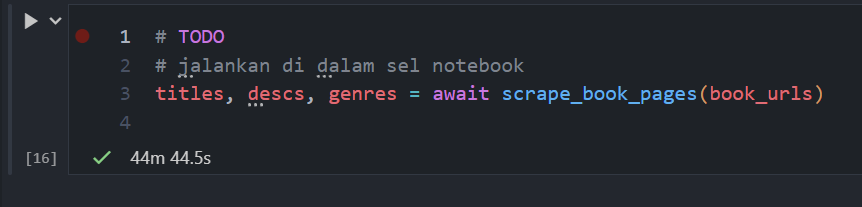
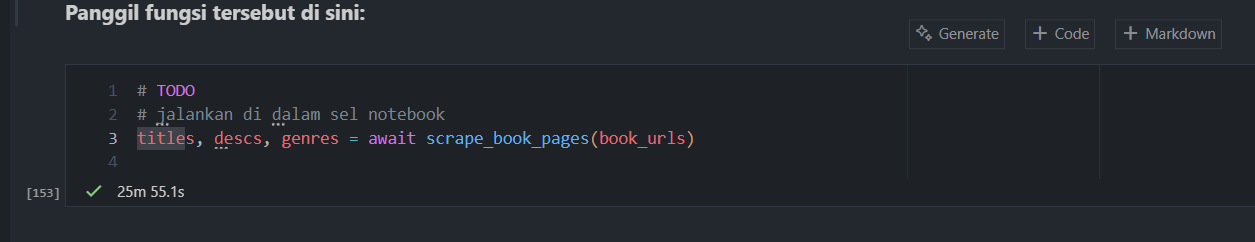

### Soal 1d

Saatnya Anda mengumpulkan semua data dalam sebuah dataset. Seperti biasa, struktur data yang digunakan adalah *dataframe* `pandas`.

**Buat dan tunjukkan *dataframe* berisi kolom-kolom berikut:**
- Judul buku
- URL buku
- Deskripsi buku
- Setiap *genre* buku unik dengan *one-hot encoding*

Misalnya, jika Anda menemukan 10 *genre* dalam hasil scraping Anda, maka *dataframe* Anda seharusnya mengandung 13 kolom.

Anda juga disarankan untuk mengunduh *dataframe* tersebut agar Anda tidak perlu mengulangi proses *scraping*.

In [17]:
# TODO
df = pd.DataFrame({
    "title": titles,
    "url":   book_urls,
    "desc":  descs,
    "genres": genres,
})

# bersihkan baris tanpa judul/desc
# df = df.dropna(subset=["title", "desc"]).reset_index(drop=True)
pd.set_option('display.max_colwidth', 80)  

# himpun genre unik
all_genres = sorted({g for gs in df["genres"] for g in gs})
for g in all_genres:
    df[g] = df["genres"].apply(lambda lst: int(g in lst))

print("Shape:", df.shape)
df.head()

pd.set_option('display.max_colwidth', None)


C:\Users\moham\AppData\Local\Temp\ipykernel_2844\1994580209.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[g] = df["genres"].apply(lambda lst: int(g in lst))
C:\Users\moham\AppData\Local\Temp\ipykernel_2844\1994580209.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[g] = df["genres"].apply(lambda lst: int(g in lst))
C:\Users\moham\AppData\Local\Temp\ipykernel_2844\1994580209.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor 

Shape: (10000, 688)


In [18]:

df.to_csv("books.csv", index=False, encoding="utf-8")

## *Text Classification*

Setelah membuat dataset dari *web scraping*, sekarang Anda diberikan tugas untuk membuat model yang mampu mengklasifikasikan sebuah buku ke dalam *genre* fiksi atau nonfiksi berdasarkan deskripsinya. Karena berdasarkan deskripsi teks, tugas ini termasuk dalam *text classification*. Dalam *teks classification* Anda perlu mengubah teks menjadi representasi numerik yang dapat dimengerti mesin. Salah satu caranya adalah dengan memetakan alias melakukan *embedding* teks ke dalam ruang vektor.

### Soal 2a

Asumsikan bahwa sebuah buku hanya bisa tergolong ke dalam salah satu *genre*. Masalahnya, Goodreads memiliki *tag* terpisah untuk kedua *genre* tersebut, sehingga ada kemungkinan sebuah buku dikategorikan sebagai buku fiksi sekaligus nonfiksi atau bukan keduanya.  Selain itu, terdapat *tag* lain yang mengindikasikan bahwa *genre* tersebut termasuk fiksi, seperti "*Historical Fiction*" atau "*Science Fiction*".

**Modifikasi *dataframe* sehingga terdiri atas kolom berikut:**
- Judul buku
- URL buku
- Deskripsi buku
- *Genre* fiksi (bernilai 1 untuk fiksi, 0 untuk nonfiksi; definisi kolom ini juga mencakup semua genre lain dengan *substring* "*fiction*")

**Hapus semua buku yang dianggap invalid berdasarkan asumsi di atas, serta buku yang tidak memiliki data fitur. Tunjukkan hasil *dataframe*, termasuk jumlah buku fiksi dan nonfiksi.**


link dataset: https://drive.google.com/file/d/1e2TuPh9toVgBQmm7cXdGWKfQDXKxElBo/view?usp=sharing

In [15]:
import pandas as pd
df2 = pd.read_csv("books.csv")

# Hanya buang baris yang tidak punya deskripsi dan judul
df2 = df2.dropna(subset=["desc", 'title']).reset_index(drop=True)

# Buat fungsi untuk mendeteksi kriteria
def classify_fiction(genre_str):
    if pd.isna(genre_str):
        return 'invalid'
    
    genre_lower = str(genre_str).lower()
    
    # Cek apakah ada 'nonfiction'
    has_nonfiction = 'nonfiction' in genre_lower
    
    # Cek apakah ada 'fiction' tapi bukan bagian dari 'nonfiction'
    # Kita perlu cek dengan hati-hati karena 'nonfiction' mengandung 'fiction'
    has_fiction = False
    
    # Pecah genre menjadi list untuk pengecekan lebih teliti
    genres = [g.strip() for g in genre_lower.split(',')]
    
    for genre in genres:
        # Cek jika genre mengandung 'fiction' tapi bukan 'nonfiction'
        if 'fiction' in genre and 'nonfiction' not in genre:
            has_fiction = True
            break
    
    # Klasifikasi berdasarkan kriteria
    if has_fiction and not has_nonfiction:
        return 'fiction'
    elif not has_fiction and has_nonfiction:
        return 'nonfiction'
    else:
        return 'invalid'  # Jika ada keduanya atau tidak ada keduanya

# Terapkan klasifikasi
df2['fiction_label'] = df2['genres'].apply(classify_fiction)

# Hapus buku dengan label invalid
print("Jumlah data sebelum difilter:", len(df2))
df2 = df2[df2['fiction_label'] != 'invalid'].reset_index(drop=True)
print("Jumlah data setelah difilter:", len(df2))

# Konversi label ke numeric untuk kemudahan analisis
df2['is_fiction'] = df2['fiction_label'].map({'fiction': 1, 'nonfiction': 0})

# Tampilkan hasil
print("Jumlah buku fiksi    :", (df2.fiction_label == 'fiction').sum())
print("Jumlah buku non-fiksi:", (df2.fiction_label == 'nonfiction').sum())

# Tampilkan sampel hasil
df2[['title', 'genres', 'fiction_label', 'is_fiction']].head(10)

Jumlah data sebelum difilter: 9985
Jumlah data setelah difilter: 9248
Jumlah buku fiksi    : 8006
Jumlah buku non-fiksi: 1242


,title,genres,fiction_label,is_fiction
0,The Hunger Games,"['young adult', 'dystopia', 'fiction', 'fantas...",fiction,1
1,Harry Potter and the Order of the Phoenix,"['fantasy', 'young adult', 'fiction', 'magic',...",fiction,1
2,Pride and Prejudice,"['classics', 'romance', 'fiction', 'historical...",fiction,1
3,To Kill a Mockingbird,"['historical fiction', 'school', 'literature',...",fiction,1
4,The Book Thief,"['historical fiction', 'fiction', 'young adult...",fiction,1
5,Twilight,"['fantasy', 'young adult', 'romance', 'fiction...",fiction,1
6,Animal Farm,"['fiction', 'dystopia', 'fantasy', 'school', '...",fiction,1
7,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,"['fantasy', 'fiction', 'classics', 'adventure'...",fiction,1
8,The Chronicles of Narnia,"['fantasy', 'classics', 'fiction', 'young adul...",fiction,1
9,The Fault in Our Stars,"['young adult', 'fiction', 'contemporary', 're...",fiction,1


### Soal 2b

Tokenisasi menjadi faktor penting ketika ingin menggunakan *embedding* kata, karena tokenisasi menentukan pembagian kata yang akan dicocokkan dengan *vocabulary embedding* tersebut.

**Lengkapi fungsi `tokenize_text` yang:**
- Menerima *string* deskripsi buku
- Menggunakan *regular expression* untuk substitusi karakter tertentu dalam *string*
- Mengembalikan *list* berisi *string* kata/token

In [16]:
import re
# Pilih paket stopwords, kamu bisa pakai NLTK atau daftar manual:
from nltk.corpus import stopwords
import nltk
nltk.download("stopwords")
STOPWORDS = set(stopwords.words("english"))

def tokenize_text(text):
    if not isinstance(text, str):
        return []
    # 1. Lowercase
    text = text.lower()
    # 2. Hapus punctuation & angka, sisakan spasi
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+",    " ", text)
    # 3. Normalize whitespace
    text = re.sub(r"\s+",    " ", text).strip()
    # 4. Split
    tokens = text.split()
    # 5. Hapus stopwords dan token pendek (<=1 char)
    tokens = [w for w in tokens 
              if w not in STOPWORDS and len(w) > 1]
    return tokens



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Lakukan tokenisasi pada contoh deskripsi `desc` berikut. Bandingkan dengan hasil yang sudah ada.**

In [17]:
desc = """
'The Sandman' is a 3-part series of award-winning graphic novels first
created in 1989. It blends modern myth and dark fantasy, in which historical
drama, contemporary fiction and legend are interwoven.
"""

In [18]:
# for comparison
tokenize_text(desc)

['sandman',
 'part',
 'series',
 'award',
 'winning',
 'graphic',
 'novels',
 'first',
 'created',
 'blends',
 'modern',
 'myth',
 'dark',
 'fantasy',
 'historical',
 'drama',
 'contemporary',
 'fiction',
 'legend',
 'interwoven']

**Jelaskan maksud setiap komponen pada *regular expression* Anda.**

* **Import dan persiapan stopwords**

  * Mengimpor modul `re` untuk operasi regular expressions.
  * Mengimpor stopwords bahasa Inggris dari NLTK dan mengunduhnya (`nltk.download("stopwords")`).
  * Menyimpan daftar stopwords dalam `STOPWORDS` untuk filtering.

* **Definisi fungsi `tokenize_text(text)`**

  1. **Cek tipe input**

     * Jika `text` bukan string, kembalikan list kosong (`[]`).
  2. **Lowercase**

     * Ubah seluruh karakter di `text` menjadi huruf kecil:

       ```python
       text = text.lower()
       ```
  3. **Hapus punctuation & angka**

     * Ganti semua karakter non-alfanumerik (selain whitespace) dengan spasi:

       ```python
       text = re.sub(r"[^\w\s]", " ", text)
       ```
     * Ganti semua angka dengan spasi:

       ```python
       text = re.sub(r"\d+", " ", text)
       ```
  4. **Normalize whitespace**

     * Hilangkan spasi berlebih (lebih dari satu) dan trim di ujung:

       ```python
       text = re.sub(r"\s+", " ", text).strip()
       ```
  5. **Split ke dalam token**

     * Pisahkan string berdasarkan spasi menjadi list kata:

       ```python
       tokens = text.split()
       ```
  6. **Filter stopwords dan token pendek**

     * Buang kata yang ada di `STOPWORDS` atau panjangnya ≤ 1 karakter:

       ```python
       tokens = [w for w in tokens 
                 if w not in STOPWORDS and len(w) > 1]
       ```
  7. **Return hasil token**

     * Kembalikan list token yang sudah dibersihkan.

### Soal 2c

Salah satu jenis *embedding* teks yang populer adalah Word2Vec. Cara kerjanya adalah dengan melatih model *neural network* sederhana untuk memprediksi kata berdasarkan konteks di sekitarnya, sehingga kata-kata dengan konteks serupa (sering berada dalam dokumen yang sama) akan memiliki nilai *embedding* yang berdekatan.

Jika Anda ingin menggunakan Word2Vec tanpa melatih model sendiri, Anda dapat menggunakan *vocabulary* hasil model *pre-trained* seperti berikut:

In [19]:
from gensim import downloader
pretrained_word2vec = gensim.downloader.load("word2vec-google-news-300")

Library `gensim` memungkinkan Anda untuk melatih model Word2Vec sendiri dari dataset Anda. Fitur ini berpotensi memberikan *embedding* kata yang lebih akurat jika corpus Anda berada dalam domain yang spesifik.

**Latihlah sebuah model Word2Vec *custom* pada seluruh dataset Anda. Samakan dimensi *embedding* dengan *pre-trained* Word2Vec pada soal 2c.**

Epoch: 1, Loss: 5378504.5
Epoch: 2, Loss: 4034270.5
Epoch: 3, Loss: 3681676.0
Epoch: 4, Loss: 3651571.0
Epoch: 5, Loss: 3326544.0
Epoch: 6, Loss: 3235180.0
Epoch: 7, Loss: 3168528.0
Epoch: 8, Loss: 3103922.0
Epoch: 9, Loss: 3023332.0
Epoch: 10, Loss: 2532512.0
Epoch: 11, Loss: 2255392.0
Epoch: 12, Loss: 2198964.0
Epoch: 13, Loss: 2174232.0
Epoch: 14, Loss: 2125324.0
Epoch: 15, Loss: 2107656.0
Epoch: 16, Loss: 2077756.0
Epoch: 17, Loss: 2035408.0
Epoch: 18, Loss: 2011708.0
Epoch: 19, Loss: 1991480.0
Epoch: 20, Loss: 1976916.0


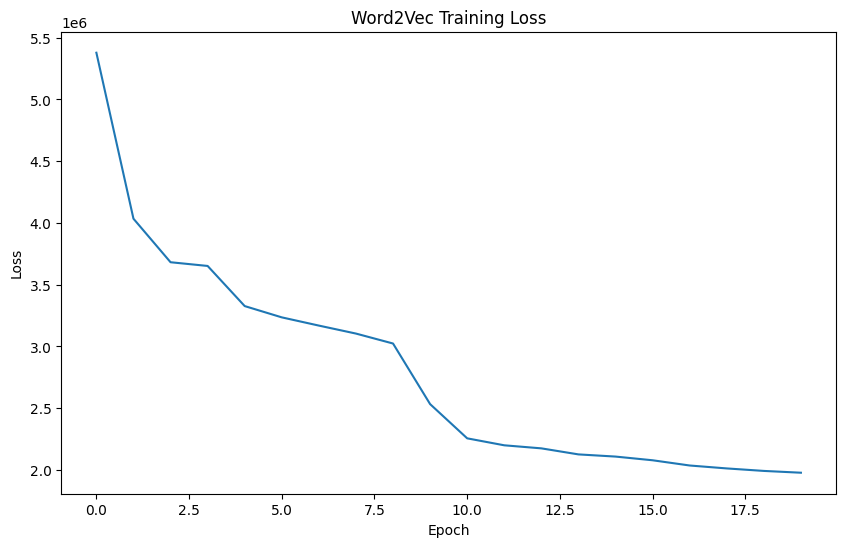

In [20]:
from gensim.models import Word2Vec
import numpy as np
from gensim.models.callbacks import CallbackAny2Vec
import matplotlib.pyplot as plt

# 1. Create a loss tracker callback to monitor training
class LossTracker(CallbackAny2Vec):
    def __init__(self):
        self.epochs = 0
        self.losses = []
        
    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epochs == 0:
            current_loss = loss
        else:
            current_loss = loss - self.loss_previous_step
        self.losses.append(current_loss)
        self.loss_previous_step = loss
        self.epochs += 1
        print(f"Epoch: {self.epochs}, Loss: {current_loss}")

# 3. Apply improved tokenization
tokenized_titles = df2["title"].map(tokenize_text).tolist()
tokenized_descs = df2["desc"].map(tokenize_text).tolist()

# 4. Create corpus with better weighting
# Give more weight to title tokens (duplicate them)
tokenized_corpus = [toks_title * 2 + toks_desc 
                   for toks_title, toks_desc in zip(tokenized_titles, tokenized_descs)]

# 5. Train improved Word2Vec
loss_tracker = LossTracker()
improved_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=300,
    window=8,         # Increased window size to capture more context
    min_count=2,      # Ignore tokens that appear less than 2 times
    sg=1,             # Use skip-gram model (often better for semantic relationships)
    negative=10,      # Number of negative samples
    ns_exponent=0.75, # Negative sampling exponent 
    alpha=0.03,       # Initial learning rate
    min_alpha=0.0007, # Final learning rate
    workers=4,
    epochs=20,        # Train for more epochs
    seed=42,
    compute_loss=True,
    callbacks=[loss_tracker]
)

custom_word2vec = improved_model.wv

# 6. Plot the loss curve to see improvements
plt.figure(figsize=(10, 6))
plt.plot(loss_tracker.losses)
plt.title('Word2Vec Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# 7. Save the model for later use
improved_model.save("improved_word2vec_model.model")

**Dapatkan *embedding* dari kata "*fantasy*", "*adventure*" dan, "*education*" menggunakan model *pre-trained* dan *custom*. Jelaskan:**
- Untuk setiap model, manakah di antara kata "*adventure*" dan "*education*" yang lebih mirip dengan "*fantasy*"?
- Apakah hasil *embedding* kata-kata tersebut menggunakan model *custom* Anda serupa dengan hasil model *pre-trained*? Mengapa demikian?

In [21]:
# TODO
for label, model in [("Pretrained", pretrained_word2vec), ("Custom", custom_word2vec)]:
    sim_adv = model.similarity("fantasy", "adventure")
    sim_edu = model.similarity("fantasy", "education")
    print(f"{label} - adventure vs fantasy: {sim_adv:.4f}, education vs fantasy: {sim_edu:.4f}")
    print(f"Closer to fantasy: {('adventure' if sim_adv > sim_edu else 'education')}\n")

Pretrained - adventure vs fantasy: 0.3936, education vs fantasy: 0.0507
Closer to fantasy: adventure

Custom - adventure vs fantasy: 0.3017, education vs fantasy: 0.1316
Closer to fantasy: adventure



Pretrained - adventure vs fantasy: 0.3936, education vs fantasy: 0.0507
Closer to fantasy: adventure

Custom - adventure vs fantasy: 0.3543, education vs fantasy: 0.1769
Closer to fantasy: adventure

### Soal 2d

Model Word2Vec hanya menghasilkan vocabulary *embedding* untuk kata, bukan dokumen. Anda dapat memperoleh *embedding* dokumen menggunakan *embedding* kata-kata dalam dokumen tersebut.

**Lengkapi fungsi `get_corpus_embedding` yang:**
- Menerima dua parameter:
  - *List* berisi hasil tokenisasi dokumen-dokumen dalam corpus dengan `tokenize_text`
  - *Keyed vector* (*vocabulary*) Word2Vec
- Mengembalikan *list* atau *array* berisi *embedding* Word2Vec dokumen (bukan kata!)

In [22]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import csr_matrix

def get_corpus_embedding(tokenized_corpus, keyed_vectors):
    # Kembali gabungkan tokens untuk CountVectorizer
    corpus_strings = [' '.join(tokens) for tokens in tokenized_corpus]
    
    # Hitung term frequency
    count_vectorizer = CountVectorizer()
    count_matrix = count_vectorizer.fit_transform(corpus_strings)
    
    # Implementasi BM25 yang efisien
    def bm25_weights(X, k1=1.5, b=0.75):
        # Jumlah kata dalam setiap dokumen
        lengths = X.sum(axis=1).A1
        
        # Rata-rata panjang dokumen
        avgdl = lengths.mean()
        
        # Jumlah dokumen
        N = X.shape[0]
        
        # IDF
        df = np.bincount(X.indices, minlength=X.shape[1])
        idf = np.log((N - df + 0.5) / (df + 0.5) + 1.0)
        
        # TF dengan normalisasi panjang dokumen
        rows, cols = X.nonzero()
        tf = X.data
        
        # Normalisasi TF dengan panjang dokumen
        norm_tf = tf / (1.0 + k1 * ((1.0 - b) + b * lengths[rows] / avgdl))
        
        # Nilai BM25 final
        values = norm_tf * idf[cols]
        
        return csr_matrix((values, (rows, cols)), shape=X.shape)
    
    # Terapkan BM25
    bm25_matrix = bm25_weights(count_matrix)
    
    # Buat kamus untuk mengakses indeks feature dengan cepat
    feature_names = count_vectorizer.get_feature_names_out()
    feature_indices = {feature: idx for idx, feature in enumerate(feature_names)}
    
    vector_size = keyed_vectors.vector_size
    default_vector = np.zeros(vector_size)
    embeddings = []
    
    # Untuk setiap dokumen
    for i, tokens in enumerate(tokenized_corpus):
        # Dapatkan non-zero entries untuk dokumen ini dari matriks BM25
        doc_vector = np.zeros(vector_size)
        total_weight = 0
        
        # Gunakan cara yang lebih efisien untuk mengakses bobot BM25
        # dengan hanya memproses token yang ada dalam dokumen dan dalam keyed_vectors
        valid_tokens = [t for t in tokens if t in keyed_vectors]
        
        # Untuk setiap valid token, ambil bobot BM25-nya
        for token in valid_tokens:
            if token in feature_indices:
                idx = feature_indices[token]
                # Ambil nilai dari matriks sparse secara efisien
                weight = bm25_matrix[i, idx] if bm25_matrix[i, idx] != 0 else 1.0
            else:
                weight = 1.0
                
            doc_vector += keyed_vectors[token] * weight
            total_weight += weight
        
        # Normalisasi
        if total_weight > 0:
            doc_vector = doc_vector / total_weight
        else:
            doc_vector = default_vector.copy()
            
        embeddings.append(doc_vector)
    
    return np.array(embeddings)

**Jelaskan:**
- Bagaimana Anda memperoleh *embedding* dokumen dari *embedding* kata-kata? Mengapa Anda menggunakan cara tersebut?
- Bagaimana Anda menangani kata *out-of-vocabulary*? Mengapa Anda menggunakan cara tersebut?
- Bagaimana Anda menangani dokumen dengan hasil `tokenize_text` kosong? Mengapa Anda menggunakan cara tersebut?

1. **Bagaimana Anda memperoleh *embedding* dokumen dari *embedding* kata-kata? Mengapa Anda menggunakan cara tersebut?**

   * **Cara**

     1. Hitung bobot BM25 untuk setiap term di tiap dokumen, sehingga kata‐kata penting (yang jarang muncul globalnya) mendapat bobot lebih tinggi.
     2. Untuk setiap dokumen, kumpulkan vektor kata (`keyed_vectors[token]`) hanya untuk token yang valid, kalikan masing‐masing dengan bobot BM25-nya, lalu jumlahkan.
     3. Bagi hasil penjumlahan itu dengan total bobot BM25 di dokumen → menghasilkan weighted average vector:

        $$
          \mathbf{v}_{\text{doc}}
          = \frac{\sum_{t\in D} \mathrm{bm25}(t,D)\,\mathbf{v}_t}
                 {\sum_{t\in D}\mathrm{bm25}(t,D)}
        $$
   * **Alasan**

     * **Menekankan kata kunci**: BM25 menyeimbangkan frekuensi term (TF) dan kelangkaan global (IDF), sehingga topik inti dokumen tampil lebih kuat.
     * **Sederhana & efisien**: weighted average masih linear time dan memanfaatkan sparse matrix, cocok untuk korpus besar.
     * **Performa**: sering kali outperform simple average karena ia memperhitungkan “signifikansi” setiap token.

2. **Bagaimana Anda menangani kata *out-of-vocabulary* (OOV)? Mengapa Anda menggunakan cara tersebut?**

   * **Cara**

     * Hanya masukkan token yang ada di `keyed_vectors` ke dalam perhitungan (`valid_tokens = [t for t in tokens if t in keyed_vectors]`).
     * OOV token diabaikan sepenuhnya (tidak mempengaruhi `doc_vector` dan `total_weight`).
   * **Alasan**

     * **Menghindari noise**: OOV umumnya kurang informatif atau salah tokenisasi, sehingga lebih baik di-skip daripada pakai vektor acak.
     * **Konsistensi dimensi**: dengan mengabaikan OOV, output tetap berdimensi sama tanpa risiko menyisipkan vektor yang tak terdefinisi.
     * **Simpel**: implementasi skip‐OOV minimal overhead dibandingkan melakukan back-off atau random init.

3. **Bagaimana Anda menangani dokumen dengan hasil `tokenize_text` kosong? Mengapa Anda menggunakan cara tersebut?**

   * **Cara**

     * Jika `total_weight == 0` (artinya tak ada token valid atau dokumen kosong), set `doc_vector = np.zeros(vector_size)`.
   * **Alasan**

     * **Representasi “kosong”**: memberi vektor nol menandakan tidak ada informasi, tanpa menambahkan bias ke korpus.
     * **Kemudahan downstream**: model yang menerima embedding tidak perlu special-case dokumen kosong—vektor nol otomatis “netral.”
     * **Konsistensi & stabilitas**: semua dokumen, termasuk yang kosong, memiliki vektor berdimensi sama, memudahkan batch processing.


### Soal 2e

Anda akan membangun dua model *classifier*, satu untuk *pre-trained* Word2Vec dan satu untuk *custom* Word2Vec. Nanti hasil keduanya akan dibandingkan untuk mengetahui model *embedding* mana yang lebih efektif dalam melakukan klasifikasi *genre*.

**Buatlah dan terapkan prosedur pelatihan dan validasi untuk *classifier pre-trained* dan *classifier custom*. Tunjukkan nilai metrik *f1 score*. Ketentuan lainnya:**
- Menggunakan seluruh dataset Anda (tidak perlu menyisihkan data untuk pengujian)
- Kedua *classifier* Anda harus menggunakan prosedur yang sama
- *Randomness* ditentukan oleh satu *seed* untuk meningkatkan *reproducibility*
- Metode (jenis *classifier*, *hyperparameter tuning*, *cross-validation*, dsb.) dibebaskan

In [40]:
# TODO
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
X_pre = get_corpus_embedding(tokenized_corpus, pretrained_word2vec)
X_cus = get_corpus_embedding(tokenized_corpus, custom_word2vec)

y = df2["is_fiction"].values

import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from joblib import dump


# 2) CV setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3) helper resampler
def get_resampler(name):
    if name=='smote':       return SMOTE(random_state=42)
    if name=='oversample':  return RandomOverSampler(random_state=42)
    if name=='undersample': return RandomUnderSampler(random_state=42)
    return None

resampling_strategy = 'smote'
resampler = get_resampler(resampling_strategy)

# 4) model & grid definitions
models = {
    "LogReg":       LogisticRegression(max_iter=1000, random_state=42),
    "LinearSVC":    LinearSVC(max_iter=10000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
}

param_grids = {
    "LogReg": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__class_weight": [None, "balanced"],
    },
    "LinearSVC": {
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__class_weight": [None, "balanced"],
    },
    "DecisionTree": {
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5, 10],
    },
}

best_pretrained = {}
best_custom     = {}

# 5) Loop tuning untuk pretrained embeddings
for name, clf in models.items():
    print(f"Tuning pretrained → {name}")
    steps = []
    if resampler:
        steps.append(('resampler', resampler))
    steps.append(('clf', clf))
    pipe = ImbPipeline(steps)

    grid = param_grids.get(name)
    if grid:
        gs = GridSearchCV(pipe, grid, scoring='f1', cv=skf, n_jobs=-1, verbose=1, refit=True)
        gs.fit(X_pre, y)
        best = gs.best_estimator_
        print(f"  Best CV f1 = {gs.best_score_:.4f}, params = {gs.best_params_}")
    else:
        best = pipe.fit(X_pre, y)
        print("  No grid → fit default")

    best_pretrained[name] = best
    dump(best, f"best_pre_{name}.joblib")
    print(f"  → saved to best_pre_{name}.joblib\n")

# 6) Loop tuning untuk custom embeddings
for name, clf in models.items():
    print(f"Tuning custom → {name}")
    steps = []
    if resampler:
        steps.append(('resampler', resampler))
    steps.append(('clf', clf))
    pipe = ImbPipeline(steps)

    grid = param_grids.get(name)
    if grid:
        gs = GridSearchCV(pipe, grid, scoring='f1', cv=skf, n_jobs=-1, verbose=1, refit=True)
        gs.fit(X_cus, y)
        best = gs.best_estimator_
        print(f"  Best CV f1 = {gs.best_score_:.4f}, params = {gs.best_params_}")
    else:
        best = pipe.fit(X_cus, y)
        print("  No grid → fit default")

    best_custom[name] = best
    dump(best, f"best_cus_{name}.joblib")
    print(f"  → saved to best_cus_{name}.joblib\n")


Tuning pretrained → LogReg
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best CV f1 = 0.9213, params = {'clf__C': 1, 'clf__class_weight': None}
  → saved to best_pre_LogReg.joblib

Tuning pretrained → LinearSVC
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best CV f1 = 0.9213, params = {'clf__C': 0.1, 'clf__class_weight': None}
  → saved to best_pre_LinearSVC.joblib

Tuning pretrained → DecisionTree
Fitting 5 folds for each of 9 candidates, totalling 45 fits
  Best CV f1 = 0.8577, params = {'clf__max_depth': 20, 'clf__min_samples_split': 2}
  → saved to best_pre_DecisionTree.joblib

Tuning custom → LogReg
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best CV f1 = 0.9389, params = {'clf__C': 1, 'clf__class_weight': None}
  → saved to best_cus_LogReg.joblib

Tuning custom → LinearSVC
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best CV f1 = 0.9371, params = {'clf__C': 0.1, 'clf__class_weight': None}
  → saved to best_cus_Li

link model: https://drive.google.com/drive/folders/1p9lX9ufzgzGi8DKmkYZ7Y79DBf-IReO6?usp=sharing

### Soal 2f

Sekarang saatnya membuktikan apakah kedua model Anda mampu mengklasifikasikan *genre* buku yang belum pernah dilihatnya. Anda diminta menggunakan [dataset ini](https://drive.google.com/file/d/1F4MOxiLFJhjdQMoA9RfQ1d1UKMPSzXxn/view?usp=drive_link), yang merupakan hasil *scraping* daftar *Best Books of 2024* dan *Nonfiction Published in Year: 2024*.

**Muat dataset *test* terlebih dahulu:**

In [41]:
# TODO
# load via direct download link
test_url = "https://drive.google.com/uc?export=download&id=1F4MOxiLFJhjdQMoA9RfQ1d1UKMPSzXxn"
test_df = pd.read_csv(test_url)
# rename columns to match
test_df = test_df[["description", "fiction"]].dropna().copy()
# tokenize and embed
test_tokens = test_df["description"].map(tokenize_text).tolist()
X_test_pre = get_corpus_embedding(test_tokens, pretrained_word2vec)
X_test_cus = get_corpus_embedding(test_tokens, custom_word2vec)
y_test = test_df["fiction"].values

**Untuk kedua model, prediksi *genre* fiksi pada dataset di atas dan bandingkan dengan label aslinya. Tunjukkan nilai metrik *f1 score* dan *confusion matrix*.**

In [ ]:
from joblib import load
from sklearn.metrics import f1_score, confusion_matrix

model_names = ["LogReg", "LinearSVC", "DecisionTree"]

print("== Pre-trained embeddings ==")
for name in model_names:
    model = load(f"best_pre_{name}.joblib")
    y_pred = model.predict(X_test_pre)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f"-- {name} --")
    print(f" Test F1: {f1:.4f}")
    print(f" Confusion Matrix:\n{cm}\n")

print("== Custom embeddings ==")
for name in model_names:
    model = load(f"best_cus_{name}.joblib")
    y_pred = model.predict(X_test_cus)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f"-- {name} --")
    print(f" Test F1: {f1:.4f}")
    print(f" Confusion Matrix:\n{cm}\n")


== Pre-trained embeddings ==
-- LogReg --
 Test F1: 0.8634
 Confusion Matrix:
[[636 115]
 [ 34 471]]

-- LinearSVC --
 Test F1: 0.8561
 Confusion Matrix:
[[628 123]
 [ 35 470]]

-- DecisionTree --
 Test F1: 0.6576
 Confusion Matrix:
[[421 330]
 [ 96 409]]

== Custom embeddings ==
-- LogReg --
 Test F1: 0.8318
 Confusion Matrix:
[[572 179]
 [ 18 487]]

-- LinearSVC --
 Test F1: 0.8325
 Confusion Matrix:
[[573 178]
 [ 18 487]]

-- DecisionTree --
 Test F1: 0.6969
 Confusion Matrix:
[[510 241]
 [106 399]]



Jelaskan:
- *Classifier* mana yang bekerja lebih baik dalam memprediksi *genre* fiksi buku? Mengapa demikian?
- Apa yang dapat dilakukan untuk meningkatkan atau memperbaiki kinerja *classifier* Anda?

| Embedding      | Classifier   | F1     | Precision | Recall |
| -------------- | ------------ | ------ | --------- | ------ |
| **Pretrained** | LogisticReg  | 0.8634 | 0.8038    | 0.9327 |
|                | LinearSVC    | 0.8561 | 0.7926    | 0.9307 |
|                | DecisionTree | 0.6576 | 0.5535    | 0.8099 |
| **Custom**     | LogisticReg  | 0.8318 | 0.7312    | 0.9644 |
|                | LinearSVC    | 0.8325 | 0.7323    | 0.9644 |
|                | DecisionTree | 0.6969 | 0.6234    | 0.7901 |

---

## 1. Classifier terbaik

* **Logistic Regression dengan pretrained embeddings** memiliki F1-score tertinggi (0.8634), precision ≈ 0.804, recall ≈ 0.933.
* LinearSVC (pretrained) hanya sedikit di bawah (F1 0.8561), sedangkan DecisionTree jauh tertinggal.
* Untuk custom embeddings, meski recall sangat tinggi (\~ 0.964), precision-nya turun (≈ 0.732), sehingga banyak false positives.

**Kesimpulan:**

> **Logistic Regression pada pretrained embeddings** bekerja paling baik—karena representasi kata pada model Google-News sudah sangat kaya dan stabil, sehingga classifier lebih mampu membedakan pola teks fiction vs non-fiction dengan baik.

---

## 2. Cara meningkatkan kinerja

1. **Adjust decision threshold**

   * Geser threshold probabilitas (mis. dari 0.5 ke 0.6–0.7) untuk menaikkan precision, mengorbankan sedikit recall.
2. **Eksperimen resampling lanjutan**

   * Coba teknik lain seperti ADASYN, SMOTEENN atau BorderlineSMOTE untuk menangani class imbalance secara lebih adaptif.
3. **Model ensemble**

   * Gabungkan beberapa classifier (voting atau stacking) untuk memanfaatkan kekuatan masing-masing.
4. **Contextual embeddings**

   * Uji BERT, RoBERTa, atau lainnya—representation kontekstual seringkali unggul dibanding Word2Vec statis.
5. **Hyperparameter tuning lebih luas**

   * Perluas ruang pencarian (mis. C, penalty, learning rate), atau gunakan Bayesian optimization untuk menemukan konfigurasi optimal secara efisien.
6. **Optimasi preprocessing**

   * Lemmatization, removal of rare words, atau domain-specific stopwords bisa meningkatkan kualitas embedding custom yang kita latih.
